<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
!pip install tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

Load Dataset (Simulated Forensics Scenario)

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Reshape
x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Create Tampered Images

In [3]:
# Add noise to simulate tampering
noise_factor = 0.5

x_test_tampered = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_test_tampered = np.clip(x_test_tampered, 0., 1.)

Build Autoencoder

In [4]:
input_img = layers.Input(shape=(28,28,1))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

Train on Authentic Images Only

In [5]:
autoencoder.fit(
    x_train, x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 219ms/step - loss: 0.1146 - val_loss: 0.1140
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 206ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 203ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 210ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 201ms/step - loss: 0.1120 - val_loss: 0.1140


Reconstruction

In [6]:
# Reconstruct images
reconstructed = autoencoder.predict(x_test)
reconstructed_tampered = autoencoder.predict(x_test_tampered)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


Compute Reconstruction Error

In [7]:
# MSE error
error_normal = np.mean((x_test - reconstructed)**2, axis=(1,2,3))
error_tampered = np.mean((x_test_tampered - reconstructed_tampered)**2, axis=(1,2,3))

print("Normal Avg Error:", np.mean(error_normal))
print("Tampered Avg Error:", np.mean(error_tampered))

Normal Avg Error: 0.11395814
Tampered Avg Error: 0.19320350894061095


Threshold for Detection

In [8]:
threshold = np.mean(error_normal) + 2*np.std(error_normal)

print("Threshold:", threshold)

# Detect anomalies
predictions = error_tampered > threshold

print("Tampered Detected:", np.sum(predictions))

Threshold: 0.19653393
Tampered Detected: 4253


Visualization

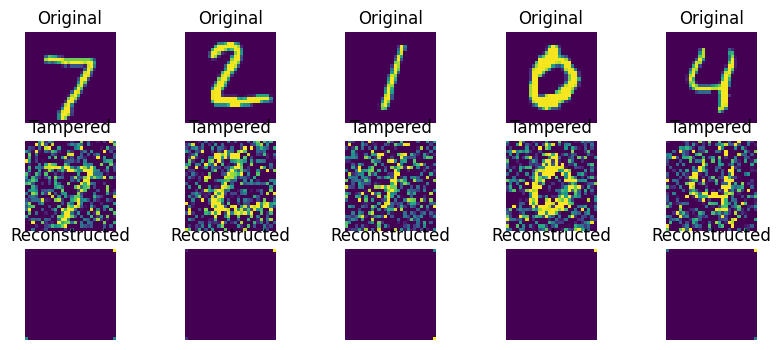

In [9]:
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.title("Original")
    plt.axis("off")

    # Tampered
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_tampered[i].reshape(28,28))
    plt.title("Tampered")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(reconstructed_tampered[i].reshape(28,28))
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()